# Тематическое моделирование статей Хабра


In [1]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import pymorphy3
from wordcloud import WordCloud, STOPWORDS
import gensim
from gensim.models import CoherenceModel

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

plt.rcParams["figure.figsize"] = (14, 6)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\000\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\000\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\000\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Загрузка датасета статей Хабра


In [2]:
df = pd.read_csv("dataset.csv")
print("Habr dataset:", df.shape)
display(df.head())


Habr dataset: (40, 7)


,FileName,UserName,TopicTitle,Tags,Date,Categories,TextArticle
0,01_1033920_e2249b78.pdf,MaKsTube,Нейросети-Художники. ChatGPT в этой роли,"Искусственный интеллект, Знания — лучшая инвес...",2026-05-12,Обзор,"Нейросети или как их ещё любят называть ""Искус..."
1,02_1033914_f4af3221.pdf,TeaDove,"Меня раздражает, как объясняют асинхронность","Python*, Go*, Для IO-bound!, Скрытый текст, Дл...",2026-05-12,Мнение,Если что такое параллелизм более-менее все раз...
2,03_1033906_86db43a4.pdf,Dingzhibo,Когда «просто проведи кастдев» — худший совет,"Управление продуктом*, Искусственный интеллект...",2026-05-12,NaN,"Нет клиентов, времени или денег — а стратегия ..."
3,04_1026818_4e38a1db.pdf,SiYa_renko,Почему классический подход к QA больше не рабо...,"Блог компании OTUS, Искусственный интеллект, Т...",2026-05-12,Мнение,"512K+ Охват за 30 дней OTUS 479,4 Рейтинг 187 ..."
4,05_1033890_e1aa3dd8.pdf,nenkre,Легко ли навайбкодить новый «Черный квадрат»?,"Карьера в IT-индустрии, Искусственный интеллек...",2026-05-12,Мнение,"С того момента, как в 2017 году восемь инженер..."


## Краткий обзор датасета


In [3]:
print("Распределение по типам (Categories):")
print(df["Categories"].value_counts(), "\n")

print("Топ тегов (Tags):")
all_tags = df["Tags"].dropna().str.split(",").explode().str.strip().str.replace("*", "", regex=False)
print(all_tags.value_counts().head(15), "\n")

print("Авторы:")
print(df["UserName"].value_counts().head(10), "\n")

print("Даты:")
print(df["Date"].value_counts().head(10))


Распределение по типам (Categories):
Categories
Кейс                      9
Обзор                     7
Мнение                    6
Туториал                  3
Ретроспектива             2
Кейс, Перевод             1
Дайджест                  1
Перевод                   1
Ретроспектива, Перевод    1
Name: count, dtype: int64 

Топ тегов (Tags):
Tags
Проложите ребенку путь в ИТ    23
Знания — лучшая инвестиция     17
Искусственный интеллект        15
Из песочницы                   10
Машинное обучение               9
Программирование                7
Python                          4
Go                              4
Карьера в IT-индустрии          4
DevOps                          4
Блог компании OTUS              3
Веб-разработка                  3
Научно-популярное               3
Управление продуктом            2
Информационная безопасность     2
Name: count, dtype: int64 

Авторы:
UserName
makarsuperstar    2
MaKsTube          1
TeaDove           1
Dingzhibo         1
SiYa_renko    

## Подготовка текста
Очистка текста, лемматизация с помощью `pymorphy3` и удаление стоп-слов.


In [4]:
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend([
    "это", "который", "свой", "весь", "еще", "ещё", "также", "тоже", "однако",
    "хабр", "статья", "автор", "читать", "написать", "комментарий", "публикация",
    "один", "два", "три", "уже", "будет", "может", "можно", "все", "всем", "всё",
    "при", "поддержке", "реклама", "перейти", "подписаться", "минуточку", "внимания",
    "простой", "средний", "сложный", "мин", "час", "назад", "поток"
])

morph = pymorphy3.MorphAnalyzer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace("\xa0", " ")
    text = re.sub(r"[^а-яёa-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def lemmatize_text(text: str) -> str:
    tokens = word_tokenize(text)
    lemmas = []
    for token in tokens:
        if token in russian_stopwords:
            continue
        if len(token) <= 2:
            continue
        if token.isdigit():
            continue
        lemma = morph.parse(token)[0].normal_form
        if lemma not in russian_stopwords and len(lemma) > 2:
            lemmas.append(lemma)
    return " ".join(lemmas)

def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data["corpus"] = (
        data["TopicTitle"].fillna("") + " " +
        data["Tags"].fillna("") + " " +
        data["Categories"].fillna("") + " " +
        data["TextArticle"].fillna("")
    )
    data["prep_text"] = data["corpus"].apply(clean_text)
    data["text_lemm"] = data["prep_text"].apply(lemmatize_text)
    data["tokenize_text"] = data["text_lemm"].apply(
        lambda txt: " ".join([t for t in word_tokenize(txt) if t not in russian_stopwords and len(t) > 2])
    )
    return data

habr_p = prepare_dataframe(df)
display(habr_p[["TopicTitle", "corpus", "text_lemm", "tokenize_text"]].head(3))


,TopicTitle,corpus,text_lemm,tokenize_text
0,Нейросети-Художники. ChatGPT в этой роли,Нейросети-Художники. ChatGPT в этой роли Искус...,нейросеть художник chatgpt роль искусственный ...,нейросеть художник chatgpt роль искусственный ...
1,"Меня раздражает, как объясняют асинхронность","Меня раздражает, как объясняют асинхронность P...",раздражать объяснять асинхронность python boun...,раздражать объяснять асинхронность python boun...
2,Когда «просто проведи кастдев» — худший совет,Когда «просто проведи кастдев» — худший совет ...,просто провести кастдева плохой совет управлен...,просто провести кастдева плохой совет управлен...


## Облако слов


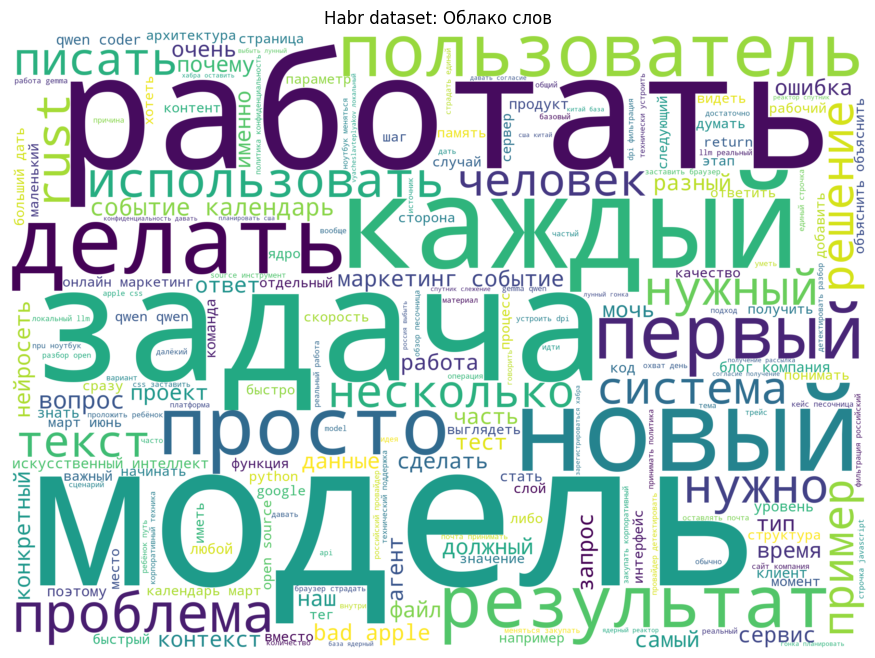

In [5]:
def get_wordcloud(text_series, title):
    corpus = " ".join(text_series.dropna().astype(str).tolist())
    wc = WordCloud(
        background_color="white",
        stopwords=STOPWORDS,
        width=2500,
        height=1800,
        max_words=200,
        random_state=42
    ).generate(corpus)
    plt.figure(figsize=(16, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

get_wordcloud(habr_p["tokenize_text"], "Habr dataset: Облако слов")


## Векторизация текстовых данных


In [6]:
count_vec = CountVectorizer(
    max_df=0.9,
    min_df=1,
    max_features=5000,
    ngram_range=(1, 3),
    analyzer="word"
)
count_matrix = count_vec.fit_transform(habr_p["tokenize_text"])

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=1,
    max_features=5000,
    ngram_range=(1, 3),
    analyzer="word"
)
tfidf_matrix = tfidf_vectorizer.fit_transform(habr_p["tokenize_text"])

print("Count matrix shape:", count_matrix.shape)
print("TF-IDF matrix shape:", tfidf_matrix.shape)


Count matrix shape: (40, 5000)
TF-IDF matrix shape: (40, 5000)


## Тематическое моделирование: LDA (sklearn)


In [7]:
def print_topics_sklearn(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Тема {topic_idx + 1}: {' '.join(top_words)}")
        print()

def run_lda(count_matrix, feature_names, n_topics=5, title=""):
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        max_iter=100
    )
    lda.fit(count_matrix)
    print("=" * 70)
    print(title)
    print("=" * 70)
    print_topics_sklearn(lda, feature_names, n_top_words=10)
    return lda

habr_lda = run_lda(count_matrix, count_vec.get_feature_names_out(), 5, "Habr dataset — LDA (sklearn)")


Habr dataset — LDA (sklearn)
Тема 1: модель работать событие пользователь каждый задача маркетинг ответить просто мочь

Тема 2: state страница google protobuf string тип value сообщение контент ratchet

Тема 3: rust модель этап пример base задача трейс работать distilled clickhouse

Тема 4: self task dag def xcom задача return key str store

Тема 5: http std сервис stream задача пользователь объяснить asio человек каждый



## LDA (Gensim) + когерентность


In [8]:
def run_gensim_lda(df: pd.DataFrame, n_topics=5, no_above=0.9, no_below=1, passes=10, random_state=42):
    token_lists = [word_tokenize(text) for text in df["text_lemm"]]
    dictionary = gensim.corpora.Dictionary(token_lists)
    dictionary.filter_extremes(no_above=no_above, no_below=no_below)
    dictionary.compactify()
    corpus = [dictionary.doc2bow(text) for text in token_lists]
    lda_model = gensim.models.LdaMulticore(
        corpus=corpus,
        num_topics=n_topics,
        id2word=dictionary,
        passes=passes,
        random_state=random_state
    )
    return dictionary, corpus, lda_model, token_lists

habr_dict, habr_corpus, habr_gensim_lda, habr_tokens = run_gensim_lda(habr_p, n_topics=5)

print("Habr Gensim LDA topics:")
for topic in habr_gensim_lda.print_topics():
    print(topic)


Habr Gensim LDA topics:
(0, '0.017*"модель" + 0.012*"self" + 0.010*"task" + 0.009*"задача" + 0.009*"dag" + 0.005*"def" + 0.004*"тест" + 0.004*"python" + 0.004*"работать" + 0.004*"xcom"')
(1, '0.005*"модель" + 0.005*"http" + 0.004*"страница" + 0.004*"каждый" + 0.004*"std" + 0.003*"событие" + 0.003*"данные" + 0.003*"контент" + 0.003*"ответить" + 0.003*"обучение"')
(2, '0.005*"protobuf" + 0.004*"value" + 0.004*"решение" + 0.004*"тип" + 0.003*"электроэнергия" + 0.003*"событие" + 0.003*"объяснить" + 0.003*"message" + 0.003*"пользователь" + 0.003*"значение"')
(3, '0.011*"rust" + 0.006*"state" + 0.006*"модель" + 0.004*"работать" + 0.004*"этап" + 0.003*"задача" + 0.003*"писать" + 0.003*"новый" + 0.003*"await" + 0.003*"string"')
(4, '0.007*"нейросеть" + 0.006*"пользователь" + 0.006*"работать" + 0.005*"модель" + 0.005*"человек" + 0.005*"бот" + 0.005*"продукт" + 0.005*"задача" + 0.004*"проблема" + 0.004*"сервис"')


In [9]:
habr_coherence = CoherenceModel(
    model=habr_gensim_lda,
    texts=habr_tokens,
    dictionary=habr_dict,
    coherence="c_v"
).get_coherence()

print("Habr coherence (c_v):", habr_coherence)


Habr coherence (c_v): 0.3877288629879223


## NMF (Non-negative Matrix Factorization)


In [10]:
def run_nmf(tfidf_matrix, feature_names, n_topics=5, n_top_words=10, title=""):
    nmf_model = NMF(n_components=n_topics, random_state=0, init="nndsvda", max_iter=400)
    nmf_model.fit(tfidf_matrix)
    print("=" * 70)
    print(title)
    print("=" * 70)
    for i, topic in enumerate(nmf_model.components_):
        words = [feature_names[j] for j in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Тема {i + 1}: {', '.join(words)}")
    return nmf_model

habr_nmf = run_nmf(tfidf_matrix, tfidf_vectorizer.get_feature_names_out(), 5, 10, "Habr dataset — NMF")


Habr dataset — NMF
Тема 1: событие, пользователь, работать, дмс, человек, делать, маркетинг, персона, ответить, каждый
Тема 2: модель, трейс, distilled, base, ssh, qwen3, oni, агент, delta, дистилляция
Тема 3: clickhouse, http, otus, nosql, система, сервис, time, тестирование, качество, продукт
Тема 4: нейросеть, бот, модель, chatgpt, studyai, ответ, галлюцинация, генерация, книга, человек
Тема 5: self, rust, task, dag, state, protobuf, string, value, torch, return


## Топ Статей по темам (NMF)


In [11]:
def top_docs_for_topics(model, tfidf_matrix, df, n_topics=5, top_docs=3, title_col="TopicTitle"):
    transformed = model.transform(tfidf_matrix)
    for topic_idx in range(min(n_topics, transformed.shape[1])):
        topic_scores = transformed[:, topic_idx]
        top_docs_idx = np.argsort(topic_scores)[-top_docs:][::-1]
        print(f"Тема {topic_idx + 1}")
        for rank, doc_idx in enumerate(top_docs_idx, 1):
            row = df.iloc[doc_idx]
            print(f"  {rank}. {row[title_col]} — уверенность: {topic_scores[doc_idx]:.3f}")
        print()

print("Habr dataset — топ статей по темам (NMF):")
top_docs_for_topics(habr_nmf, tfidf_matrix, habr_p, n_topics=5, top_docs=3)


Habr dataset — топ статей по темам (NMF):
Тема 1
  1. Легко ли навайбкодить новый «Черный квадрат»? — уверенность: 0.339
  2. NF интерфейсы — новый слой поверх классического UI — уверенность: 0.317
  3. Даже дождь выглядит как интеграция: История одной профдеформации — уверенность: 0.315

Тема 2
  1. Хотел упростить мониторинг проектов и в отпуск — пришлось обучать свой LLM.Часть 3.Дистилляция — уверенность: 0.767
  2. Хотел упростить мониторинг проектов и в отпуск — пришлось обучать свой LLM.Часть 2.Обучение — уверенность: 0.758
  3. Локальные LLM в реальной работе: Gemma 4, Qwen 3.6 и Qwen Coder — уверенность: 0.385

Тема 3
  1. Почему классический подход к QA больше не работает (и виновата ли в этом эпоха ИИ) — уверенность: 0.592
  2. ClickHouse для больших данных: полный гайд по интеграции с NoSQL‑экосистемой — уверенность: 0.588
  3. Почему ваш Go‑сервис ломается под 1000 RPS и как найти узкое место за полчаса — уверенность: 0.565

Тема 4
  1. Почему нейросеть уверенно врёт — и пр

## LSA (Latent Semantic Analysis)


In [12]:
def run_lsa(tfidf_matrix, feature_names, n_topics=5, n_top_words=10, title=""):
    lsa_model = TruncatedSVD(n_components=n_topics, random_state=0)
    lsa_model.fit(tfidf_matrix)
    print("=" * 70)
    print(title)
    print("=" * 70)
    for i, topic in enumerate(lsa_model.components_):
        words = [feature_names[j] for j in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Тема {i + 1}: {', '.join(words)}")
    return lsa_model

habr_lsa = run_lsa(tfidf_matrix, tfidf_vectorizer.get_feature_names_out(), 5, 10, "Habr dataset — LSA")


Habr dataset — LSA
Тема 1: модель, нейросеть, работать, пользователь, задача, событие, человек, каждый, делать, продукт
Тема 2: модель, трейс, base, distilled, ssh, qwen3, oni, delta, тест, дистилляция
Тема 3: http, clickhouse, otus, std, rust, time, nosql, state, объяснить, сервис
Тема 4: нейросеть, бот, модель, clickhouse, chatgpt, генерация, otus, studyai, telegram, книга
Тема 5: self, task, нейросеть, dag, http, корутина, python, std, def, torch
